In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
from liesel_ptm.model import OnionPTMLocScale
from liesel_ptm.nodes import VarInverseGamma, LinearTerm
from liesel_ptm import history_to_df
import plotnine as p9
import pandas as pd

In [3]:
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)

beta = jnp.array([0.0, 1.0, -0.5])
X = jax.random.uniform(k1, shape=(1000, 3), minval=-2.0, maxval=2.0)
y = X @ beta + jax.random.exponential(k2, shape=(X.shape[0],))

Xd = jnp.c_[jnp.ones(X.shape[0]), X]
beta_hat = jnp.linalg.inv(Xd.T @ Xd) @ Xd.T @ y

In [4]:
model = OnionPTMLocScale(
    y=y, 
    nparam=15, 
    tau2=VarInverseGamma(0.01, concentration=2.0, scale=0.5, name="tau2"),
)

model.loc_model += LinearTerm(x=X, name="lin")

In [5]:
res1 = model.optimize_locscale(atol=0.001, max_iter=1000, patience=300)

liesel_ptm.model - INFO - Optimizing location and scale parameters.
liesel_ptm.model - INFO - Building model graph. No changes to the model can be made after this step.


liesel.model.model - INFO - Converted dtype of Data(name="lin_coef_value").value
Training loss: 1576.399, Validation loss: 1576.399:  46%|████▌     | 459/999 [00:08<00:03, 166.19it/s]liesel_ptm.model - INFO - Optimizing location and scale parameters finished after 459 iterations.


In [6]:
res2 = model.optimize_transformation(atol=0.001, max_iter=1000, patience=300)

liesel_ptm.model - INFO - Optimizing transformation parameters.
Training loss: 1331.745, Validation loss: 1331.745: 100%|██████████| 999/999 [00:12<00:00, 162.99it/s]liesel_ptm.model - INFO - Optimizing transformation parameters finished after 999 iterations.


In [7]:
hist1 = history_to_df(res1.history)
hist1.head()

,loss_train,loss_validation,lin_coef0,lin_coef1,lin_coef2,iteration
0,1979.606689,1979.606689,0.000000,0.000000,0.000000,0
1,1972.744385,1972.744385,0.010000,0.010000,-0.010000,1
2,1965.930298,1965.930420,0.019568,0.020001,-0.019998,2
3,1959.158813,1959.158936,0.027946,0.030003,-0.029993,3
4,1952.413086,1952.413086,0.034011,0.040007,-0.039983,4


<Axes: xlabel='iteration'>

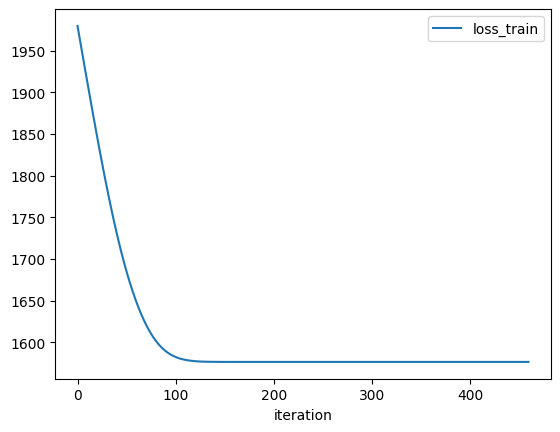

In [8]:
hist1[["loss_train", "iteration"]].plot("iteration")

<Axes: xlabel='iteration'>

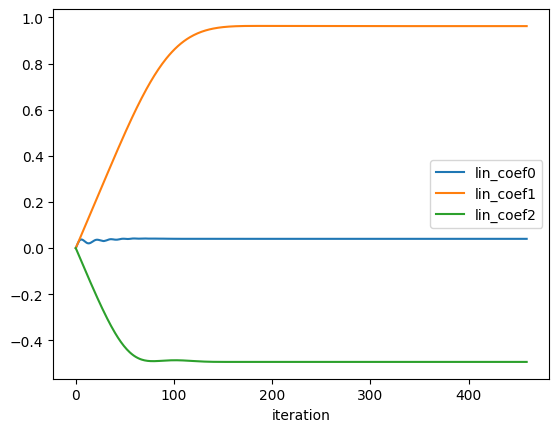

In [9]:
history_to_df(res1.history["position"]).plot("iteration")

<Axes: xlabel='iteration'>

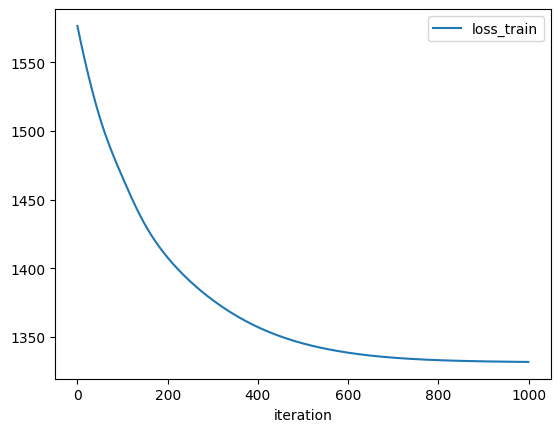

In [10]:
history_to_df(res2.history)[["loss_train", "iteration"]].plot("iteration")

<Axes: xlabel='iteration'>

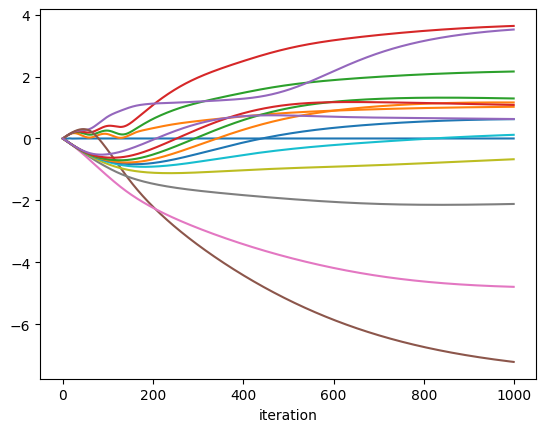

Training loss: 1331.745, Validation loss: 1331.745: 100%|██████████| 999/999 [00:30<00:00, 162.99it/s]

In [12]:
history_to_df(res2.history["position"]).plot("iteration", legend=False)

<Axes: xlabel='iteration'>

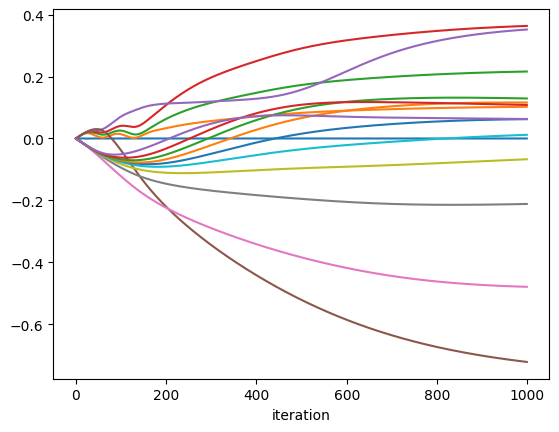

In [13]:
pos = res2.history["position"] | {model.tau2.transformed.name: model.tau2.transformed.value}

coef_hist2 = model.coef.log_increments.predict(pos)
history_to_df({"coef": coef_hist2}).plot("iteration", legend=False)

<Axes: xlabel='iteration'>

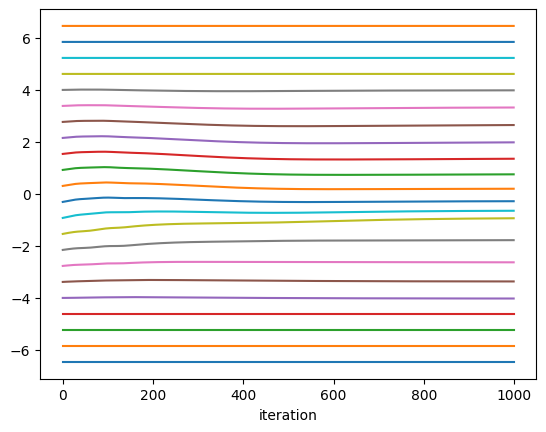

In [14]:
coef_hist2 = model.coef.predict(pos)
history_to_df({"coef": coef_hist2}).plot("iteration", legend=False)

In [15]:
dist = model.init_dist()
residual, _ = dist.transformation_and_logdet_parametric(model.response.value)
z, _ = dist.transformation_and_logdet(model.response.value)

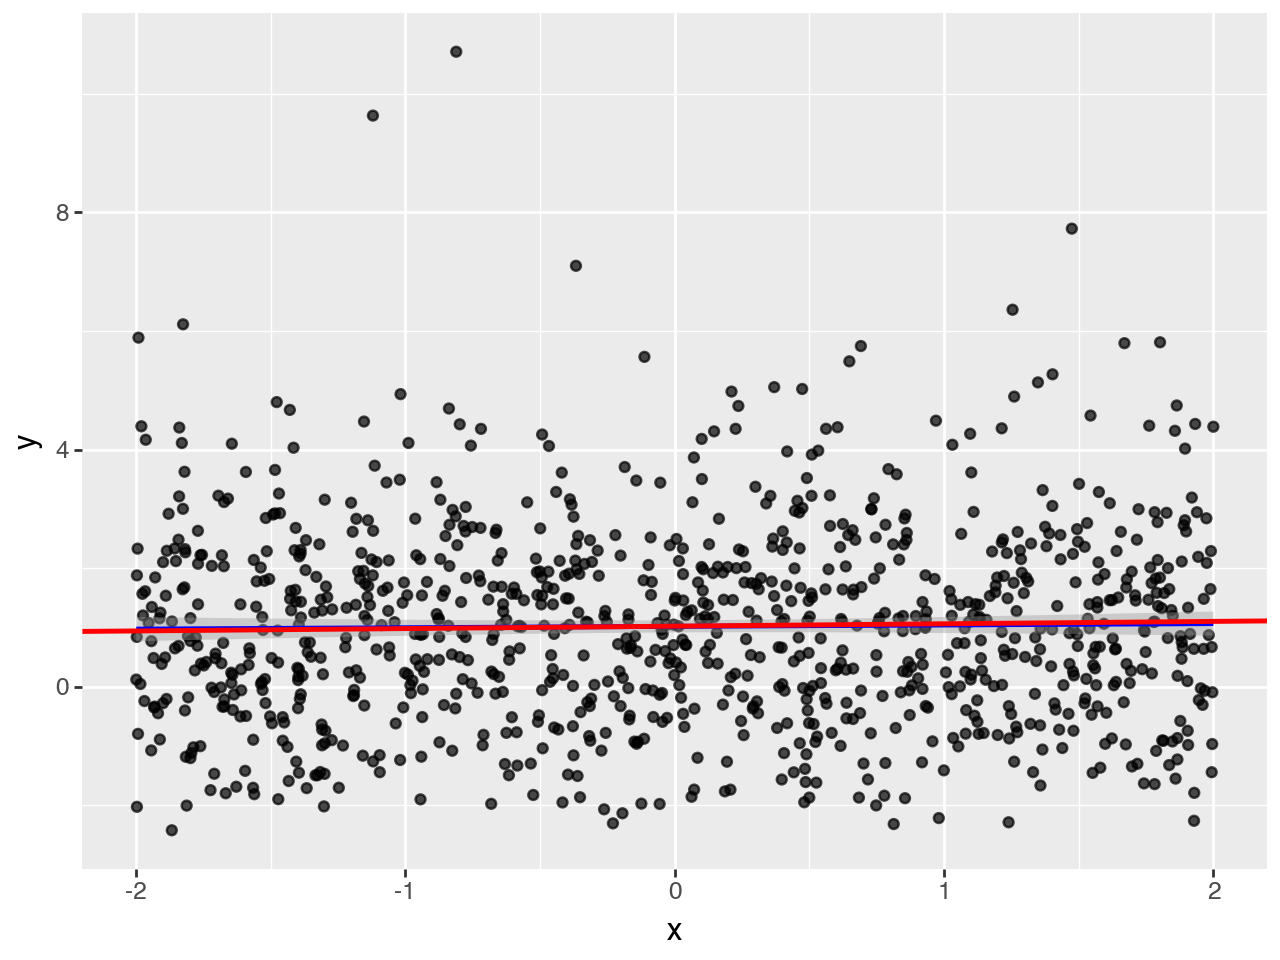

In [16]:
xi = 0
x = X[:,xi]
b0 = model.loc_intercept.value
b = np.asarray(res1.position["lin_coef"][xi])
df = pd.DataFrame(
    {"y": model.response.value, "residual": residual, "z": z, "loc": model.loc.value, "x": x}
)

(
    p9.ggplot(df)
    + p9.aes("x", "y")
    + p9.geom_point(alpha=0.7)
    + p9.geom_smooth(method = "lm", color="blue")
    + p9.geom_abline(intercept=b0, slope=b, color="red", size=1)
)

In [17]:
dist = model.dist_class(model.knots.knots, model.coef.value, loc=0.0, scale=1.0)

In [18]:
mean = dist._transformation_spline_mean()
print(mean)

[-1.208354]


In [19]:
dist._transformation_spline_variance(mean)

Array([0.7338855], dtype=float32)

In [20]:
residual = jnp.linspace(-4, 4, 301)
pdf = dist.prob(residual)
z, _ = dist.transformation_and_logdet(residual)

df = pd.DataFrame({"residual": residual, "pdf": pdf, "z": z})

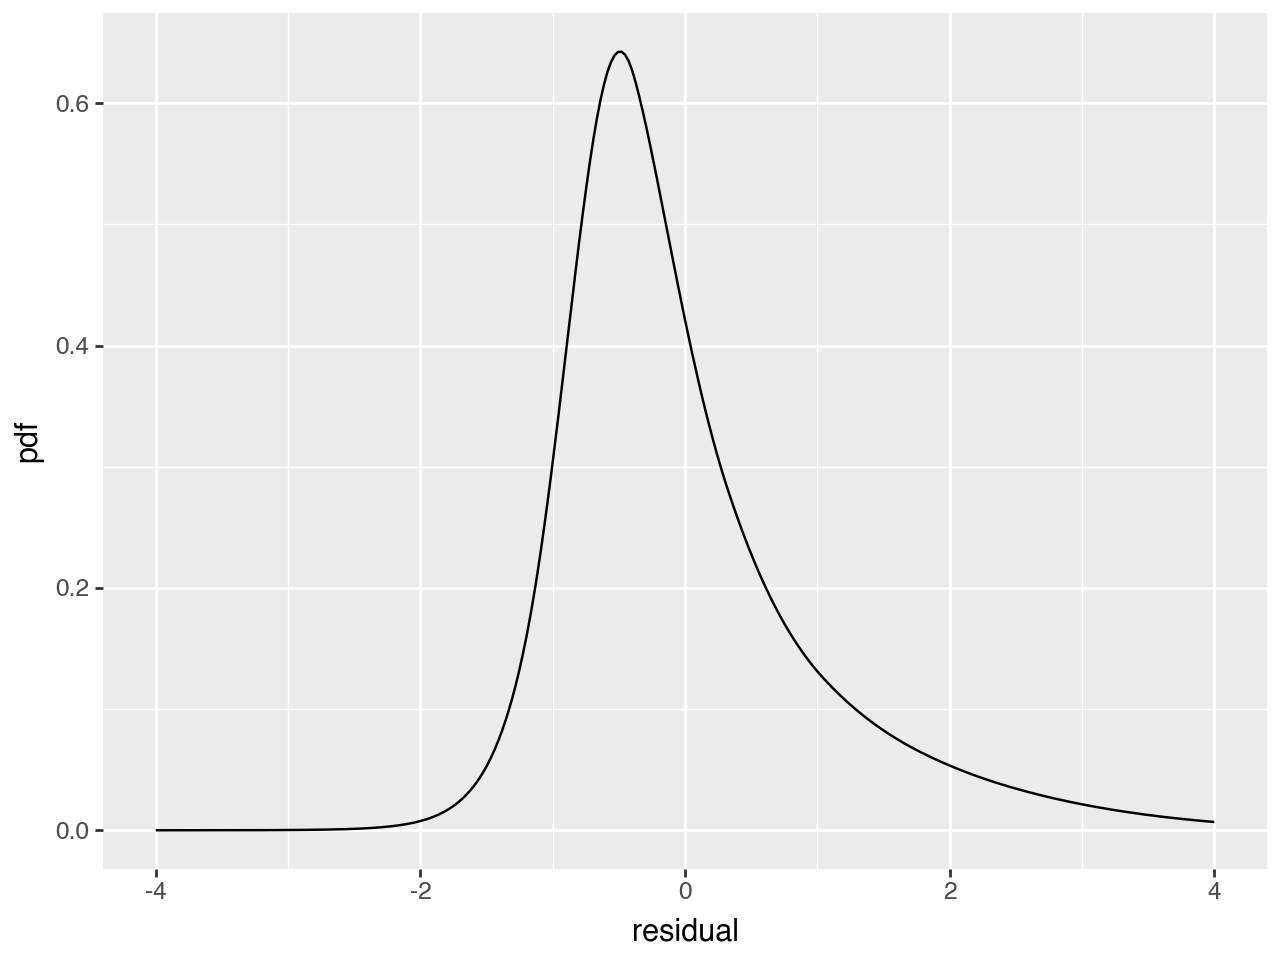

In [21]:
(
    p9.ggplot(df)
    + p9.geom_line(p9.aes("residual", "pdf"))
)

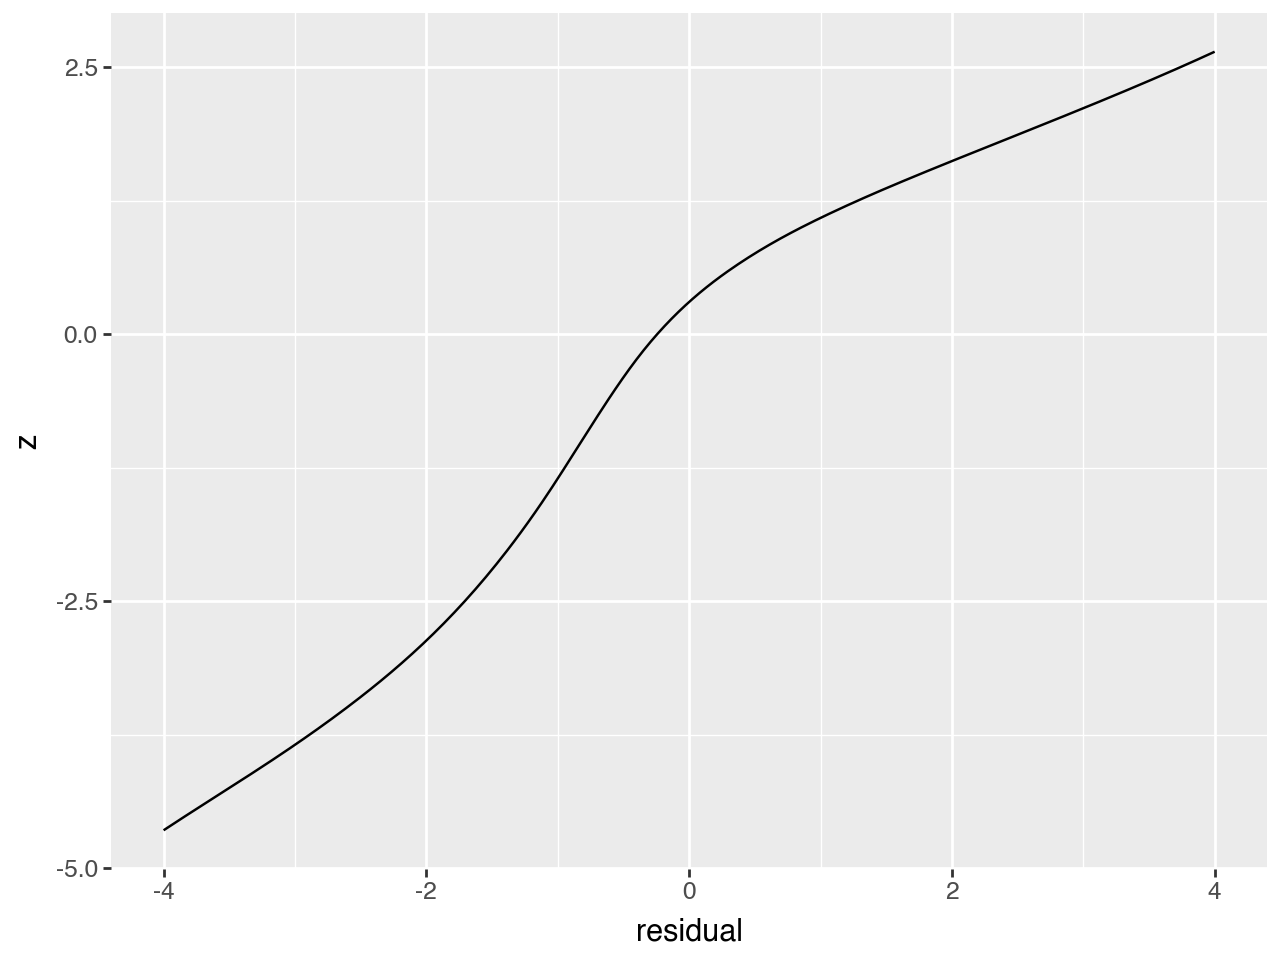

In [22]:
(
    p9.ggplot(df)
    + p9.geom_line(p9.aes("residual", "z"))
)

In [23]:
model = OnionPTMLocScale(
    y=y, 
    nparam=15, 
    tau2=VarInverseGamma(0.01, concentration=2.0, scale=0.5, name="tau2"),
    centered=False,
    scaled=False
)

model.loc_model += LinearTerm(x=X, name="lin")

In [24]:
res1 = model.optimize_locscale(atol=0.001, max_iter=1000, patience=300)

liesel_ptm.model - INFO - Optimizing location and scale parameters.
liesel_ptm.model - INFO - Building model graph. No changes to the model can be made after this step.
liesel.model.model - INFO - Converted dtype of Data(name="lin_coef_value").value
Training loss: 1576.399, Validation loss: 1576.399:  46%|████▌     | 459/999 [00:05<00:02, 181.47it/s]liesel_ptm.model - INFO - Optimizing location and scale parameters finished after 459 iterations.


In [25]:
res2 = model.optimize_transformation(atol=0.001, max_iter=1000, patience=300)

liesel_ptm.model - INFO - Optimizing transformation parameters.
Training loss: 1390.097, Validation loss: 1390.097: 100%|██████████| 999/999 [00:08<00:00, 205.19it/s]liesel_ptm.model - INFO - Optimizing transformation parameters finished after 999 iterations.


Training loss: 1576.399, Validation loss: 1576.399:  46%|████▌     | 459/999 [00:23<00:02, 181.47it/s]

<Axes: xlabel='iteration'>

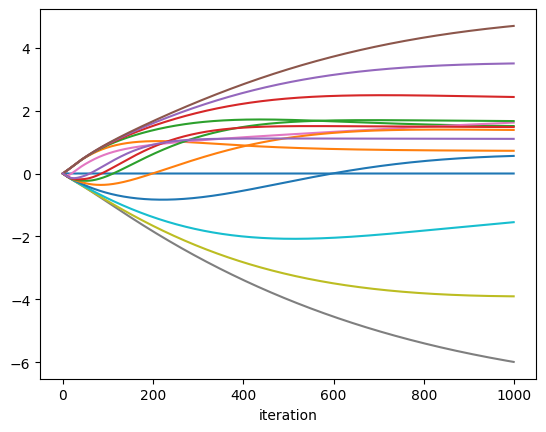

Training loss: 1390.097, Validation loss: 1390.097: 100%|██████████| 999/999 [00:26<00:00, 205.19it/s]

In [26]:
history_to_df(res2.history["position"]).plot("iteration", legend=False)

<Axes: xlabel='iteration'>

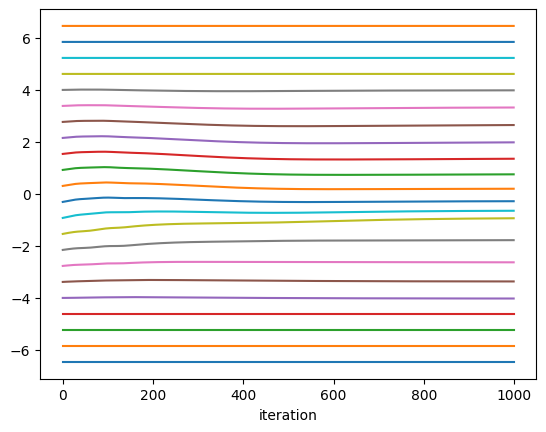

In [27]:
coef_hist2 = model.coef.predict(pos)
history_to_df({"coef": coef_hist2}).plot("iteration", legend=False)

In [28]:
dist = model.dist_class(model.knots.knots, model.coef.value, loc=0.0, scale=1.0)
residual = jnp.linspace(-4, 4, 301)
pdf = dist.prob(residual)
z, _ = dist.transformation_and_logdet(residual)

df = pd.DataFrame({"residual": residual, "pdf": pdf, "z": z})

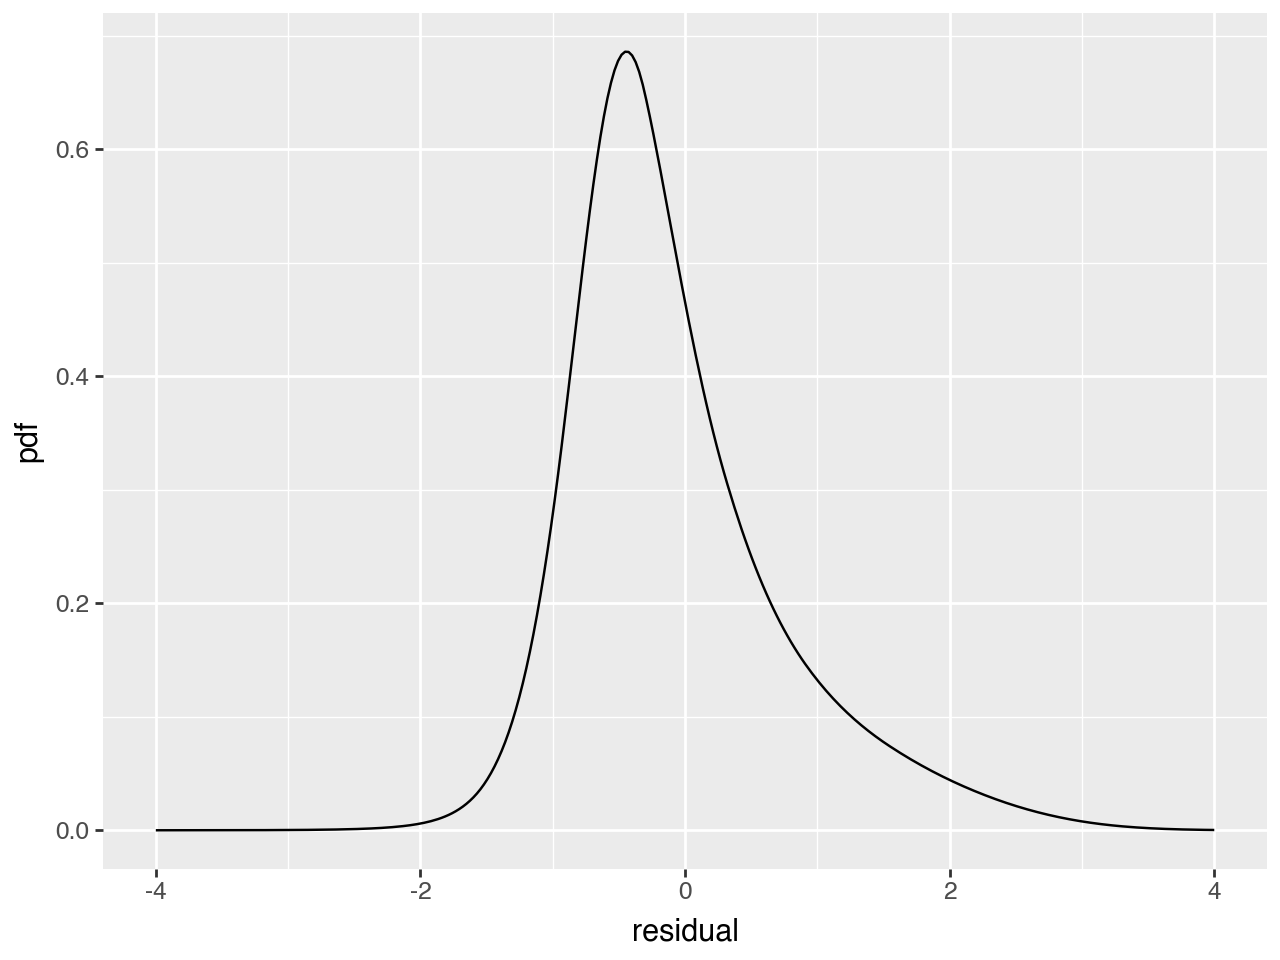

In [29]:
(
    p9.ggplot(df)
    + p9.geom_line(p9.aes("residual", "pdf"))
)

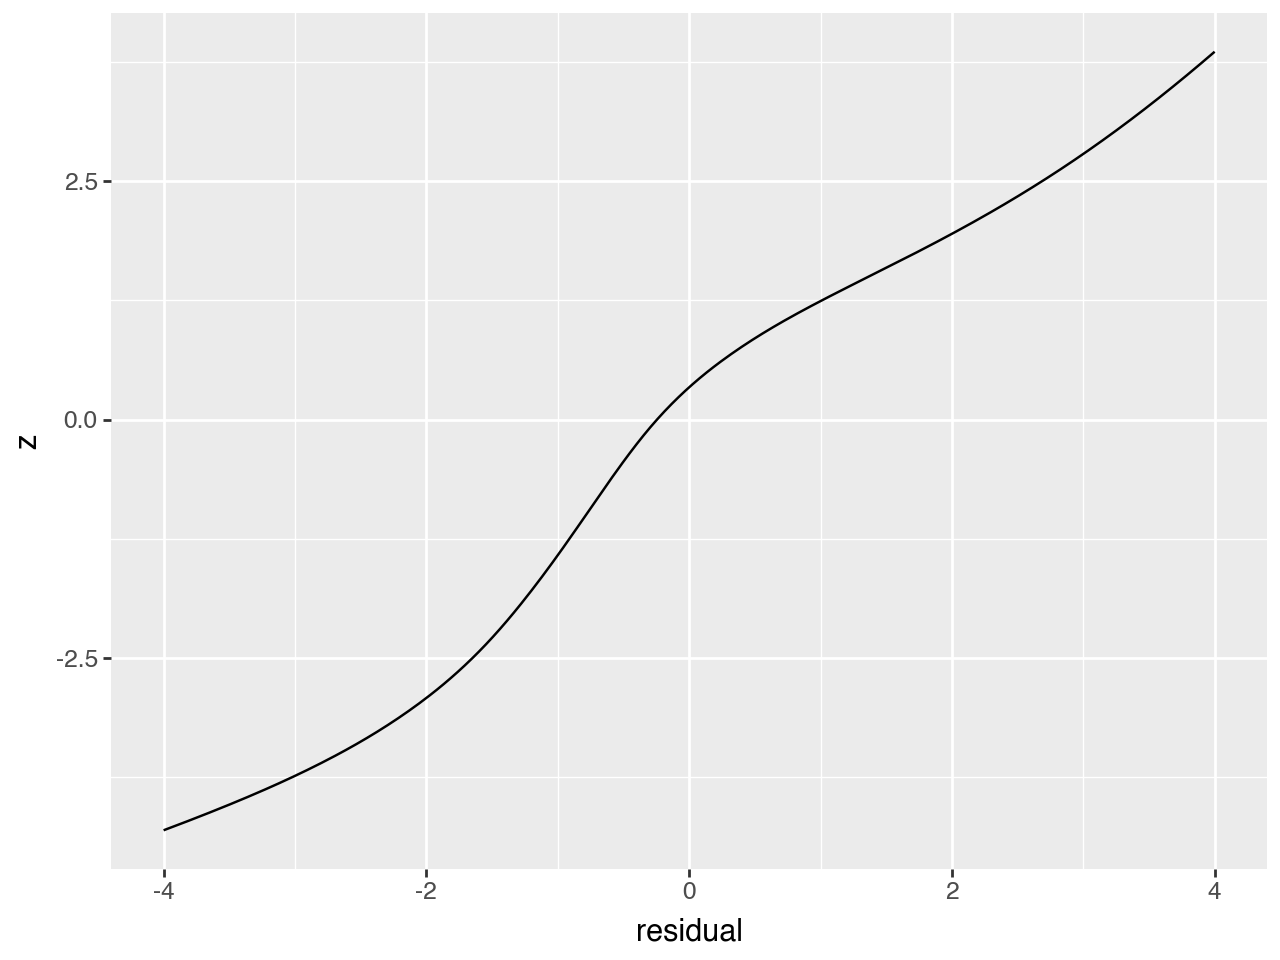

In [30]:
(
    p9.ggplot(df)
    + p9.geom_line(p9.aes("residual", "z"))
)